# **Unzip the data files**

In [2]:
import zipfile
import os

# Paths to zip files
zip_files = ['seg_train.zip', 'seg_test.zip', 'seg_pred.zip']

# Unzip all files
for zfile in zip_files:
    if os.path.exists(zfile):
        print(f"Extracting {zfile}...")
        with zipfile.ZipFile(zfile, 'r') as zip_ref:
            zip_ref.extractall('.')  # extracts into current folder
    else:
        print(f"{zfile} not found, please place it in the same folder as this script.")

print("✅ All files extracted successfully!")


Extracting seg_train.zip...
Extracting seg_test.zip...
Extracting seg_pred.zip...
✅ All files extracted successfully!


# **Loading and Preprocessing the Dataset**

In [3]:
import tensorflow as tf
import os

def load_datasets(base_dir=".", img_size=(150,150), batch_size=32):
    # Paths to train and test folders
    train_dir = os.path.join(base_dir, 'seg_train')
    test_dir  = os.path.join(base_dir, 'seg_test')

    if not os.path.exists(train_dir):
        raise FileNotFoundError("❌ Training folder not found. Make sure seg_train.zip was extracted properly.")

    # Load training dataset
    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        train_dir,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=True,
        label_mode='int'
    )

    # Load testing (validation) dataset
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
        label_mode='int'
    )

    # Get class names before prefetching
    class_names = train_ds.class_names

    # Improve performance with prefetch
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)

    # Return datasets and class names
    return train_ds, val_ds, class_names


# ---------- Test the function ----------
train_ds, val_ds, class_names = load_datasets(".", img_size=(150,150), batch_size=32)
print("✅ Classes found:", class_names)
print("🔹 Number of training batches:", len(train_ds))
print("🔹 Number of validation batches:", len(val_ds))

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
✅ Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
🔹 Number of training batches: 439
🔹 Number of validation batches: 94


# **Building the AlexNet model**

In [7]:
from tensorflow.keras import layers, models

def build_alexnet(input_shape=(150,150,3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # 1️⃣ First Convolution Block
    x = layers.Conv2D(96, (11,11), strides=4, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3,3), strides=2)(x)

    # 2️⃣ Second Convolution Block
    x = layers.Conv2D(256, (5,5), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((3,3), strides=2)(x)

    # 3️⃣ Third, Fourth, Fifth Convolution Blocks
    x = layers.Conv2D(384, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(384, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3,3), strides=2)(x)

    # 4️⃣ Fully Connected Layers
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(4096, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # 5️⃣ Output Layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='AlexNet')
    return model


# ---------- Test the model ----------
model = build_alexnet(input_shape=(150,150,3), num_classes=6)
model.summary()








Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 35, 35, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 17, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │        24,582 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,995,782 (114.42 MB)

 Trainable params: 29,995,078 (114.42 MB)

 Non-trainable params: 704 (2.75 KB)

# **Training, Evaluating, and Saving the Model**

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.

🚀 Starting training...

Epoch 1/30


439/439 - 26s - 58ms/step - accuracy: 0.6261 - loss: 0.9911 - val_accuracy: 0.6530 - val_loss: 0.8809
Epoch 2/30
439/439 - 13s - 31ms/step - accuracy: 0.7629 - loss: 0.6729 - val_accuracy: 0.6167 - val_loss: 1.0364
Epoch 3/30
439/439 - 13s - 31ms/step - accuracy: 0.8002 - loss: 0.5591 - val_accuracy: 0.6667 - val_loss: 1.0047
Epoch 4/30
439/439 - 13s - 30ms/step - accuracy: 0.8292 - loss: 0.4837 - val_accuracy: 0.6270 - val_loss: 1.1649
Epoch 5/30


439/439 - 18s - 40ms/step - accuracy: 0.8504 - loss: 0.4217 - val_accuracy: 0.7230 - val_loss: 0.7449
Epoch 6/30


439/439 - 17s - 39ms/step - accuracy: 0.8687 - loss: 0.3657 - val_accuracy: 0.7863 - val_loss: 0.6048
Epoch 7/30
439/439 - 13s - 30ms/step - accuracy: 0.8844 - loss: 0.3243 - val_accuracy: 0.7563 - val_loss: 0.7417
Epoch 8/30
439/439 - 13s - 30ms/step - accuracy: 0.9024 - loss: 0.2727 - val_accuracy: 0.7400 - val_loss: 0.8602
Epoch 9/30
439/439 - 20s - 47ms/step - accuracy: 0.9167 - loss: 0.2314 - val_accuracy: 0.7697 - val_loss: 0.7436
Epoch 10/30
439/439 - 13s - 30ms/step - accuracy: 0.9322 - loss: 0.1935 - val_accuracy: 0.8073 - val_loss: 0.6622
Epoch 11/30
439/439 - 13s - 29ms/step - accuracy: 0.9389 - loss: 0.1756 - val_accuracy: 0.7670 - val_loss: 0.8261
Epoch 12/30


439/439 - 19s - 44ms/step - accuracy: 0.9443 - loss: 0.1540 - val_accuracy: 0.8387 - val_loss: 0.5780
Epoch 13/30
439/439 - 13s - 29ms/step - accuracy: 0.9539 - loss: 0.1270 - val_accuracy: 0.8063 - val_loss: 0.8119
Epoch 14/30
439/439 - 13s - 30ms/step - accuracy: 0.9623 - loss: 0.1128 - val_accuracy: 0.7467 - val_loss: 1.0998
Epoch 15/30
439/439 - 13s - 30ms/step - accuracy: 0.9606 - loss: 0.1161 - val_accuracy: 0.8220 - val_loss: 0.7678
Epoch 16/30
439/439 - 13s - 29ms/step - accuracy: 0.9641 - loss: 0.1006 - val_accuracy: 0.7617 - val_loss: 0.9429
Epoch 17/30
439/439 - 13s - 30ms/step - accuracy: 0.9741 - loss: 0.0751 - val_accuracy: 0.8263 - val_loss: 0.9199
Epoch 18/30
439/439 - 13s - 29ms/step - accuracy: 0.9676 - loss: 0.0984 - val_accuracy: 0.8047 - val_loss: 0.8771
Epoch 19/30
439/439 - 13s - 30ms/step - accuracy: 0.9736 - loss: 0.0809 - val_accuracy: 0.8010 - val_loss: 0.8037
Epoch 20/30
439/439 - 13s - 30ms/step - accuracy: 0.9753 - loss: 0.0740 - val_accuracy: 0.8013 - val

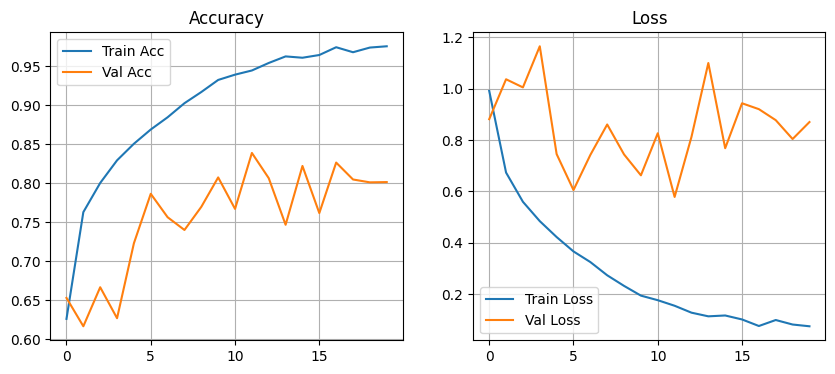


📊 Evaluating model on validation set...
94/94 - 1s - 11ms/step - accuracy: 0.8387 - loss: 0.5780
✅ Validation Accuracy: 0.8387, Loss: 0.5780
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━

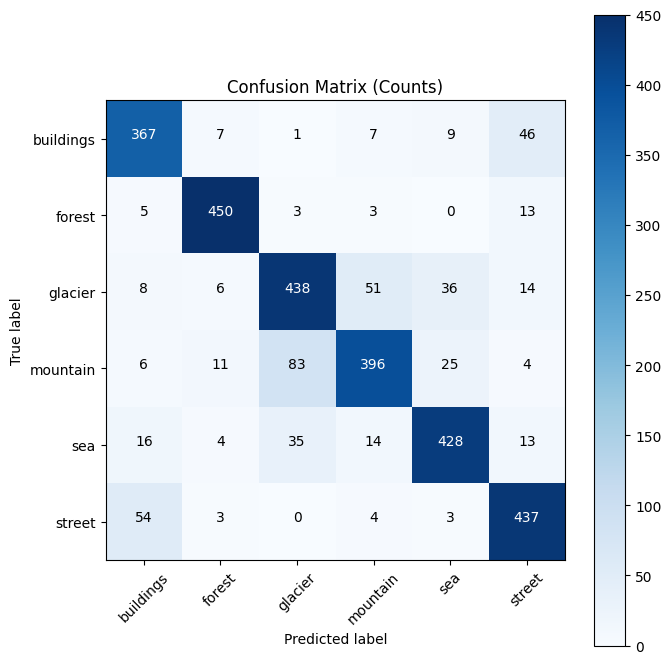

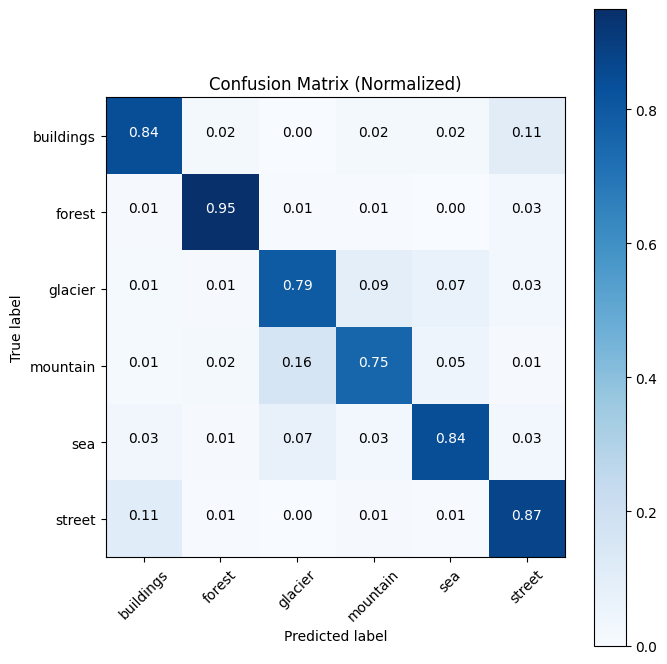


💾 Model saved to folder: intel_alexnet_model.keras/


In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import itertools
from tensorflow.keras import callbacks

# --------------------------
# Helper: Plot Confusion Matrix
# --------------------------
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45)
    plt.yticks(ticks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


# --------------------------
# Training and Evaluation
# --------------------------
def train_and_evaluate(model, train_ds, val_ds, class_names, epochs=30):
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    cb = [
        callbacks.ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True),
        callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    ]

    # Train model
    print("\n🚀 Starting training...\n")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cb,
        verbose=2
    )

    # Plot training curves
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend(); plt.title('Accuracy'); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Loss'); plt.grid(True)
    plt.show()

    # Evaluate model
    print("\n📊 Evaluating model on validation set...")
    loss, acc = model.evaluate(val_ds, verbose=2)
    print(f"✅ Validation Accuracy: {acc:.4f}, Loss: {loss:.4f}")

    # Generate predictions
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    # Classification report
    print("\n🧾 Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, class_names, title="Confusion Matrix (Counts)")
    plot_confusion_matrix(cm, class_names, normalize=True, title="Confusion Matrix (Normalized)")

    # Save model
    model.save("intel_alexnet_model.keras")
    print("\n💾 Model saved to folder: intel_alexnet_model.keras/")


# --------------------------
# Run the whole process
# --------------------------
# Assuming you already ran Parts 2 and 3:
# train_ds, val_ds, class_names = load_datasets(".", (150,150), 32)
# model = build_alexnet((150,150,3), len(class_names))

# Load datasets and build the model
train_ds, val_ds, class_names = load_datasets(".", (150,150), 32)
model = build_alexnet((150,150,3), len(class_names))

train_and_evaluate(model, train_ds, val_ds, class_names, epochs=30)




